# Task One

## Web scraping from Filmcrave



In [ ]:
%pip install -r requirements.txt

from bs4 import BeautifulSoup
import requests
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib as plt


## Functions

### Fetch Page Content Safely

In [ ]:
def fetch_page (url):
    html_content = ""
    try:
        response = requests.get(url, verify=False)
        if response.status_code == 200:
            html_content = str(response.content)
    except:
        html_content = ""
    return html_content

### Parse Movie Data from Downloaded Page

In [ ]:

def parse_movie_data (html_content):
          
    movie_data = {}
    
    # Create Soup using HTML Parser
    soup = BeautifulSoup(html_content, 'html.parser')

    # Extract movie data
    meta_tags = soup.find_all('meta', property=True)

    # Extract and print the property and content attributes
    for tag in meta_tags:
        property_name = tag.get('property')
        if property_name == "og:title":
            movie_data['title'] = tag.get('content')
        

   # try:
    movie_data['overall_rank'] = int(soup.find('span', string=lambda x: x and 'Overall Rank:' in x).find_next('span', {'class': 'orange-bold'}).string.split("/")[0])
    movie_data['average_rating'] = float(soup.find('span', string=lambda x: x and 'Average Rating:' in x).find_next('span', {'class': 'orange-bold'}).string.split("/")[0])
    #except:
        #movie_data['overall_rank'] = 0
        #movie_data['average_rating'] = 0
        
    keywords = [
            'Theatrical Release Date',
            'Language',
            'Genre',
            'MPAA Rating',
            'Director',
            'Actors',
            'Plot'
        ]
    
    for keyword in keywords:
        search_word = keyword + ": "
        key = keyword.replace(' ','_').lower()
        try:
            movie_data[key] = soup.find('span', string=lambda x: x and search_word in x).next_sibling.strip()
        except:
            movie_data[key] = "Unknown"

    return movie_data

### Fetch a Number of Pages from the Top Movie List

In [ ]:
def fetch_n_pages_of_top_movie_urls (n):
    
    # 10 movies per page
    fetch_pages = n + 1 
    # list of urls
    urls = []
    
    website = "https://www.filmcrave.com"
    base_url = "https://www.filmcrave.com/list_top_movie.php?page="
    
    print (f"Fetching: ",end="")
    for page in range(1,fetch_pages):
        print (".",end="")
        url = base_url+str(page)
        html_content = fetch_page (url)
        if len(html_content) > 0:
            # get links
            soup = BeautifulSoup(html_content, 'html.parser')
            links = soup.find_all('a')
            link_count = 0
            for link in links:
                href = link.get('href')
                if href:
                    if "movie_page_main" in str(href):
                        movie_url = website+str(href)
                        urls.append (movie_url)
                        
    urls= list(dict.fromkeys(urls))
    return (urls)

## Fetching Movie Data

### Fetch the top 120 pages of "Top Movies"
This collects a list of 1000+ URLs for the top movies.

This will take appox 4 minutes to run:

In [ ]:
urls = fetch_n_pages_of_top_movie_urls (120)

### Fetch the actual movie data
This collects data for each of the movies by scraping data from each URL in the list.

This will take approx 15 minutes to run:

In [ ]:
movie_list = []

print ('Working ',end='')

for url in urls:
    html_data = fetch_page(url)
    if len(html_data) > 0:
        movie_data = parse_movie_data (html_data)
        movie_list.append(movie_data)
        print ('.', end='')
        
print (' Finished!')

### Save to a Dataframe

In [ ]:
df = pd.DataFrame(movie_list)
df.head(100)

In [ ]:
df = df[df['overall_rank'] < 1001]

In [ ]:
df.to_csv('movie_data.csv',index = False)

## Load the Data back into a data frame and analyse

In [79]:
new_df = pd.read_csv('movie_data.csv')
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   title                    1000 non-null   object 
 1   overall_rank             1000 non-null   int64  
 2   average_rating           1000 non-null   float64
 3   theatrical_release_date  1000 non-null   object 
 4   language                 1000 non-null   object 
 5   genre                    1000 non-null   object 
 6   mpaa_rating              1000 non-null   object 
 7   director                 1000 non-null   object 
 8   actors                   1000 non-null   object 
 9   plot                     1000 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 78.2+ KB


<Axes: xlabel='language'>

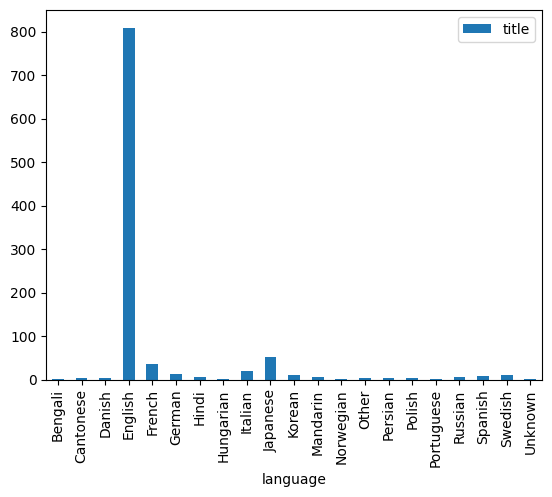

In [80]:
new_df.groupby(['language']).count().plot(y='title',kind='bar')

<Axes: xlabel='mpaa_rating'>

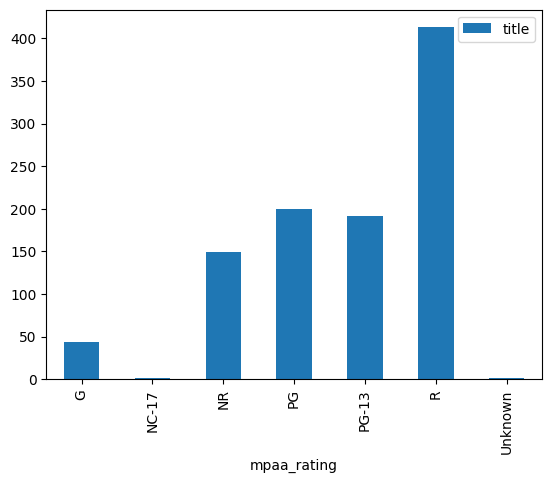

In [81]:
new_df.groupby(['mpaa_rating']).count().plot(y='title',kind='bar')

<Axes: xlabel='genre'>

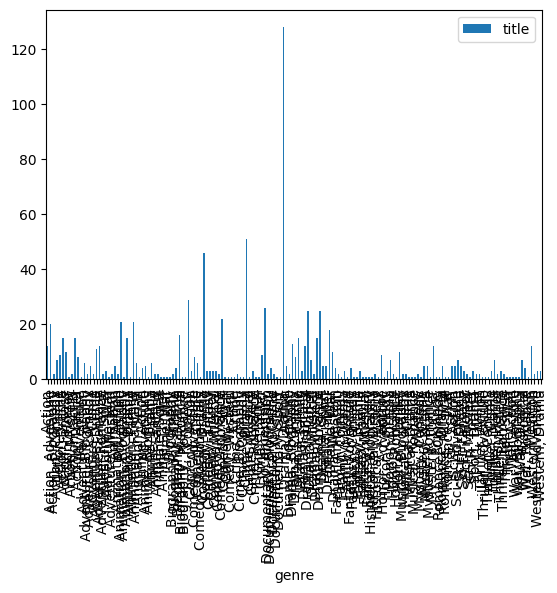

In [82]:
new_df.groupby(['genre']).count().plot(y='title',kind='bar')